In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from csbdeep.utils import axes_dict, plot_some, plot_history
from csbdeep.utils.tf import limit_gpu_memory
from csbdeep.io import load_training_data
from csbdeep.models import Config, CARE

I0000 00:00:1759981055.463588   75624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1759981055.534601   75624 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1759981057.193028   75624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(X,Y), (X_val,Y_val), axes = load_training_data('./data/training_merged_ypermuted.npz', validation_split=0.1, verbose=True)

c = axes_dict(axes)['C'] 
n_channel_in, n_channel_out = X.shape[c], Y.shape[c]

number of training images:	 14695
number of validation images:	 1633
image size (3D):		 (96, 32, 32)
axes:				 SZYXC
channels in / out:		 1 / 1


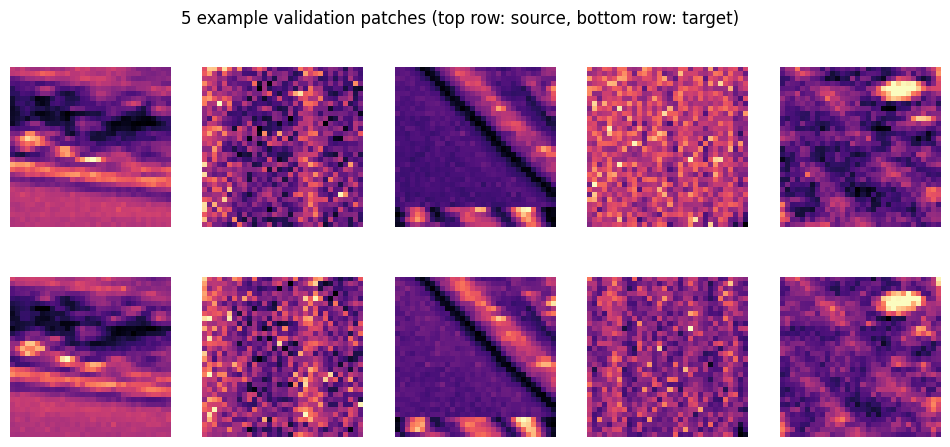

In [3]:
plt.figure(figsize=(12,5))
plot_some(X_val[:5],Y_val[:5])
plt.suptitle('5 example validation patches (top row: source, bottom row: target)');

In [4]:
config = Config(
    axes= axes,                # 3D with channel-last
    n_channel_in=1,
    n_channel_out=1,
    probabilistic=False,
    unet_residual=True,
    unet_n_depth=4,
    unet_kern_size=3,
    unet_n_first=32,
    train_epochs=100,
    train_steps_per_epoch=100,
)
print(config)
vars(config)

Config(n_dim=3, axes='ZYXC', n_channel_in=1, n_channel_out=1, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', probabilistic=False, unet_residual=True, unet_n_depth=4, unet_kern_size=3, unet_n_first=32, unet_last_activation='linear', unet_input_shape=(None, None, None, 1), train_loss='mae', train_epochs=100, train_steps_per_epoch=100, train_learning_rate=0.0004, train_batch_size=16, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 10, 'min_delta': 0})


{'n_dim': 3,
 'axes': 'ZYXC',
 'n_channel_in': 1,
 'n_channel_out': 1,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'probabilistic': False,
 'unet_residual': True,
 'unet_n_depth': 4,
 'unet_kern_size': 3,
 'unet_n_first': 32,
 'unet_last_activation': 'linear',
 'unet_input_shape': (None, None, None, 1),
 'train_loss': 'mae',
 'train_epochs': 100,
 'train_steps_per_epoch': 100,
 'train_learning_rate': 0.0004,
 'train_batch_size': 16,
 'train_tensorboard': True,
 'train_reduce_lr': {'factor': 0.5, 'patience': 10, 'min_delta': 0}}

In [5]:
model = CARE(config, 'ypermute_model_4layers', basedir='models')

W0000 00:00:1759981137.313639   75624 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1759981137.317885   75624 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1759981137.497563   75624 gpu_device.cc:2040] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29041 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [6]:
history = model.train(X,Y, validation_data=(X_val,Y_val))

Epoch 1/100


I0000 00:00:1759981153.230670   76604 service.cc:158] XLA service 0x702a940039b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759981153.230696   76604 service.cc:166]   StreamExecutor device (0): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1759981153.310539   76604 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1759981153.776750   76604 cuda_dnn.cc:463] Loaded cuDNN version 91002


  1/100 ━━━━━━━━━━━━━━━━━━━━ 20:19 12s/step - loss: 0.0569 - mae: 0.0569 - mse: 0.0064

I0000 00:00:1759981162.436848   76604 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0577 - mae: 0.0577 - mse: 0.0065

/opt/venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=('Tensor(shape=(1, 96, 32, 32, 1))',)
  warnings.warn(msg)


100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - loss: 0.0550 - mae: 0.0550 - mse: 0.0059 - val_loss: 0.0498 - val_mae: 0.0498 - val_mse: 0.0049 - learning_rate: 4.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0510 - mae: 0.0510 - mse: 0.0051 - val_loss: 0.0493 - val_mae: 0.0493 - val_mse: 0.0048 - learning_rate: 4.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0507 - mae: 0.0507 - mse: 0.0051 - val_loss: 0.0488 - val_mae: 0.0488 - val_mse: 0.0047 - learning_rate: 4.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0503 - mae: 0.0503 - mse: 0.0050 - val_loss: 0.0487 - val_mae: 0.0487 - val_mse: 0.0047 - learning_rate: 4.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0497 - mae: 0.0497 - mse: 0.0049 - val_loss: 0.0487 - val_mae: 0.0487 - val_mse: 0.0047 - learning_rate: 4.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0499 - mae: 0.0499 - mse: 0.0050 - val_loss: 0

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


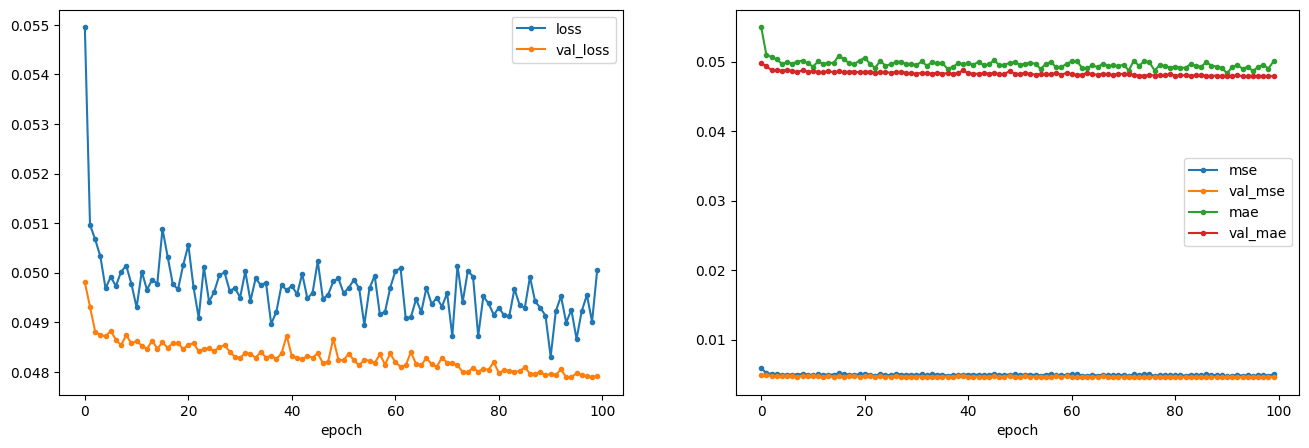

In [8]:
print(sorted(list(history.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [10]:
import tensorflow as tf
opt = model.keras_model.optimizer

# Works in TF2.x
try:
    opt.learning_rate.assign(2e-4)
except AttributeError:
    # Older TF/Keras uses .lr
    tf.keras.backend.set_value(opt.lr, 2e-4)

history2 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0495 - mae: 0.0495 - mse: 0.0049 - val_loss: 0.0479 - val_mae: 0.0479 - val_mse: 0.0046 - learning_rate: 2.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0487 - mae: 0.0487 - mse: 0.0047 - val_loss: 0.0479 - val_mae: 0.0479 - val_mse: 0.0046 - learning_rate: 2.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0492 - mae: 0.0492 - mse: 0.0048 - val_loss: 0.0479 - val_mae: 0.0479 - val_mse: 0.0046 - learning_rate: 2.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0496 - mae: 0.0496 - mse: 0.0049 - val_loss: 0.0480 - val_mae: 0.0480 - val_mse: 0.0046 - learning_rate: 2.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0488 - mae: 0.0488 - mse: 0.0048 - val_loss: 0.0479 - val_mae: 0.0479 - val_mse: 0.0046 - learning_rate: 2.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0489 - mae: 0.0489 - mse: 0.0048 - 

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


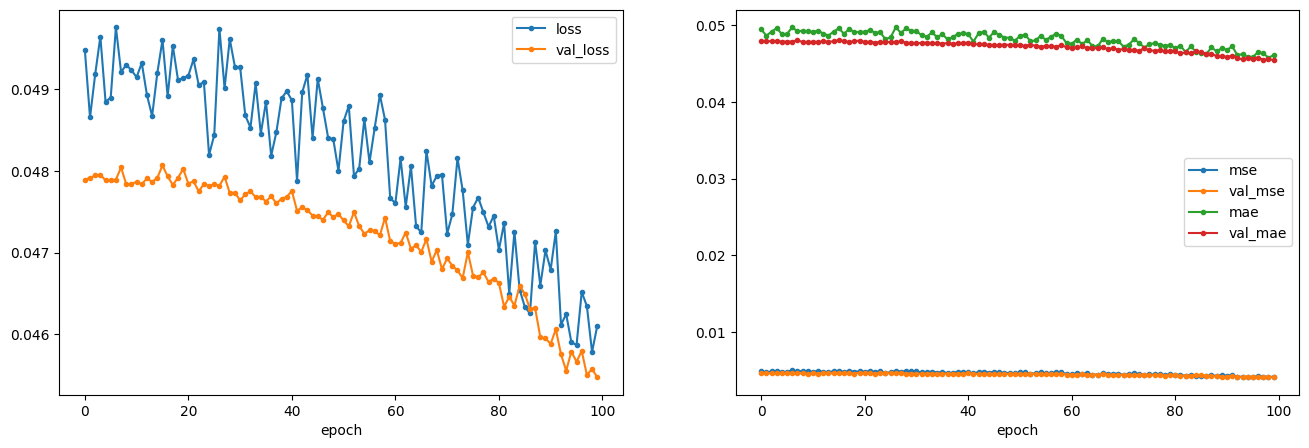

In [11]:
print(sorted(list(history2.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history2,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [12]:
history3 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0453 - mae: 0.0453 - mse: 0.0040 - val_loss: 0.0452 - val_mae: 0.0452 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0455 - mae: 0.0455 - mse: 0.0040 - val_loss: 0.0452 - val_mae: 0.0452 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0451 - mae: 0.0451 - mse: 0.0039 - val_loss: 0.0452 - val_mae: 0.0452 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0448 - mae: 0.0448 - mse: 0.0039 - val_loss: 0.0450 - val_mae: 0.0450 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0458 - mae: 0.0458 - mse: 0.0041 - val_loss: 0.0453 - val_mae: 0.0453 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0459 - mae: 0.0459 - mse: 0.0041 -

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


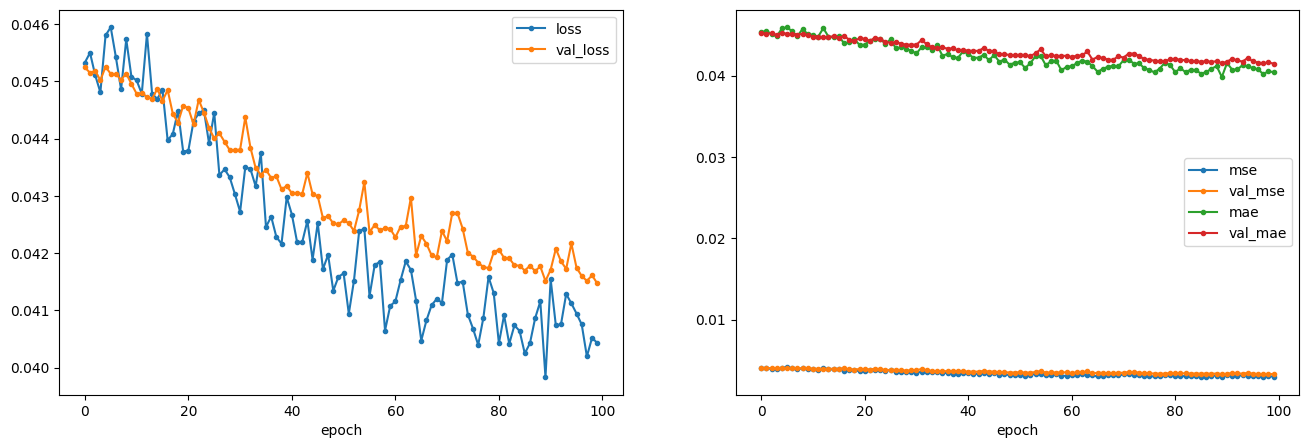

In [14]:
print(sorted(list(history3.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history3,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [16]:
import tensorflow as tf
opt = model.keras_model.optimizer

# Works in TF2.x
try:
    opt.learning_rate.assign(1e-4)
except AttributeError:
    # Older TF/Keras uses .lr
    tf.keras.backend.set_value(opt.lr, 1e-4)
history4 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0033 - learning_rate: 1.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0402 - mae: 0.0402 - mse: 0.0030 - val_loss: 0.0413 - val_mae: 0.0413 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0033 - learning_rate: 1.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0413 - val_mae: 0.0413 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0402 - mae: 0.0402 - mse: 0.0030 - val_loss: 0.0412 - val_mae: 0.0412 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0401 - mae: 0.0401 - mse: 0.0029 - v

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


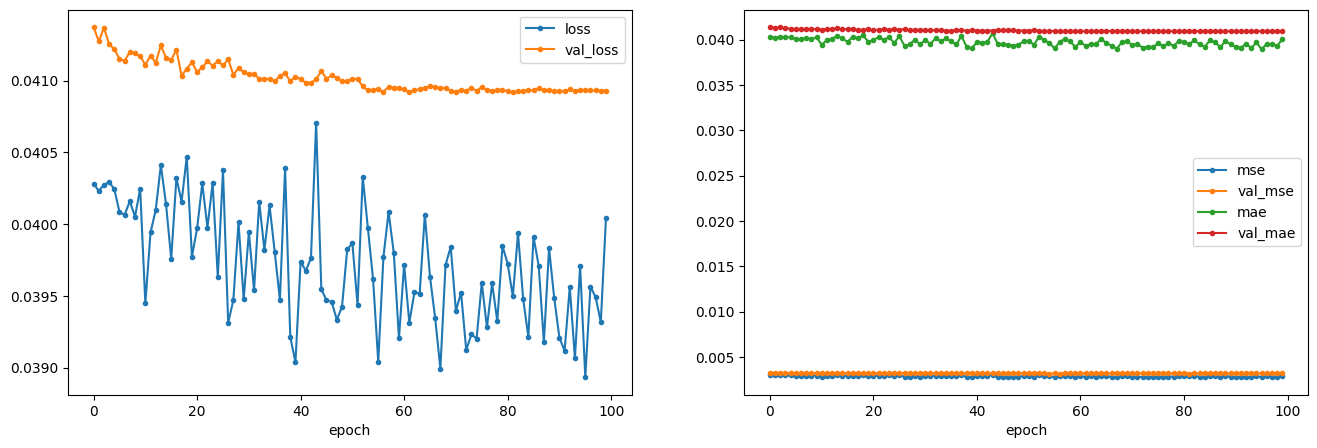

In [18]:
print(sorted(list(history4.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history4,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


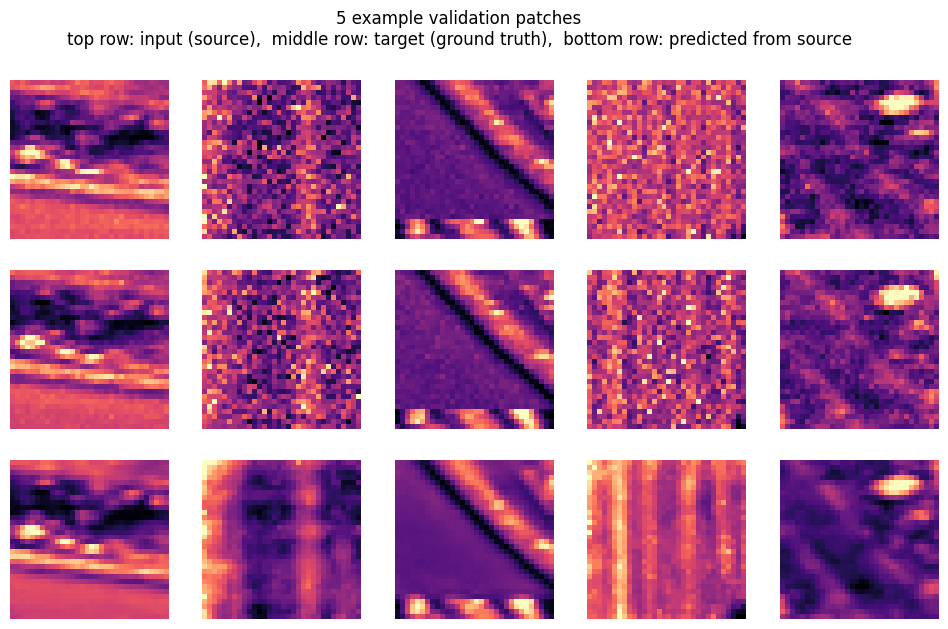

In [19]:
plt.figure(figsize=(12,7))
_P = model.keras_model.predict(X_val[:5])
if config.probabilistic:
    _P = _P[...,:(_P.shape[-1]//2)]
plot_some(X_val[:5],Y_val[:5],_P,pmax=99.5)
plt.suptitle('5 example validation patches\n'      
             'top row: input (source),  '          
             'middle row: target (ground truth),  '
             'bottom row: predicted from source');

In [11]:
print(_P.shape)

(5, 32, 96, 96, 1)
